# Customer Churn Prediction Project

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Phase 1: Data Understanding

In [2]:
df=pd.read_csv("C:/Users/User/Desktop/Customer_Churn/Telco-Customer-Churn.csv")

In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.shape

(7043, 21)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [6]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [7]:
df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [8]:
df["Churn"].value_counts(normalize=True)*100

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

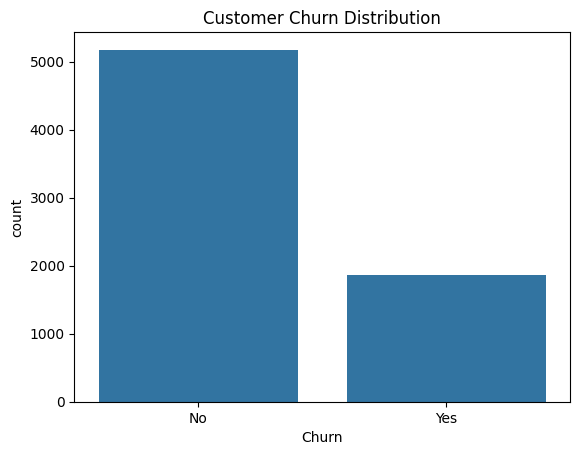

In [9]:
sns.countplot(data=df,x="Churn")
plt.title("Customer Churn Distribution")
plt.show()

# Phase 2: Exploratory Data Analysis

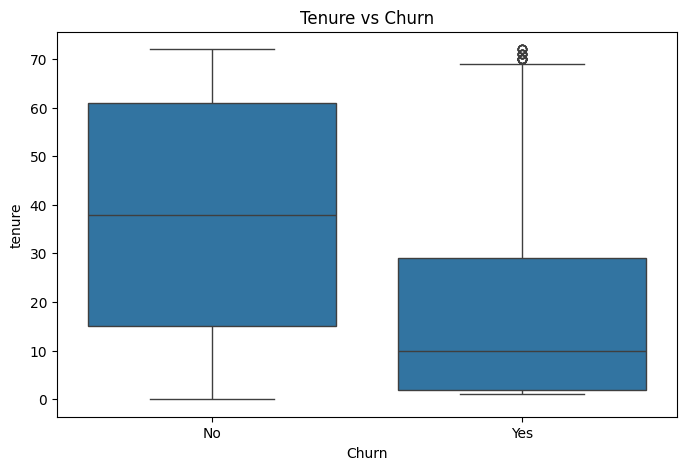

In [10]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df,
            x="Churn",
            y="tenure")
plt.title("Tenure vs Churn")
plt.show()


Observation: #Customers who churn have a much lower median tenure than customers who stay.
#The median tenure for churned customers is around 10 months.
#The median tenure for non-churned customers is around 38 months.
#A few customers with very high tenure also churn, but they are rare.

Business Insight:
#Newer customers appear more likely to leave the company.
#Customer retention efforts should focus on the first few months after acquisition.
#Tenure is likely to be an important predictor for churn prediction.

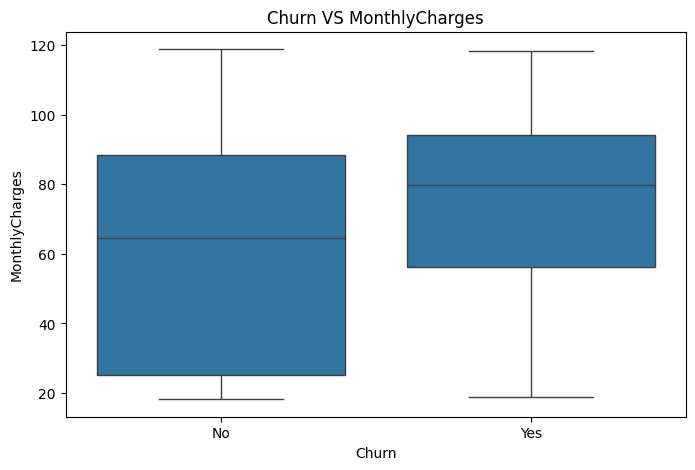

In [11]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df,
            x="Churn",
            y="MonthlyCharges")
plt.title("Churn VS MonthlyCharges")
plt.show()

Observation: 
#The median monthly charge for churned customers is approximately 80.
#The median monthly charge for non-churned customers is approximately 65.
#Churned customers generally have higher monthly charges.

Business Insight:
#Customers with higher monthly charges appear more likely to leave the company.
#Pricing may be a factor influencing customer churn.
#MonthlyCharges is likely to be an important feature for the churn prediction model.

In [12]:
pd.crosstab(
    df["Contract"],df["Churn"])

Churn,No,Yes
Contract,,
Month-to-month,2220,1655
One year,1307,166
Two year,1647,48


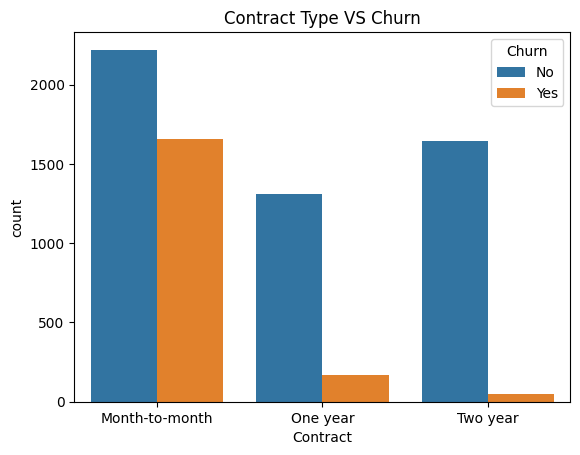

In [13]:
sns.countplot(data=df,
              x="Contract",
              hue="Churn")
plt.title("Contract Type VS Churn")
plt.show()

In [14]:
contract_churn=pd.crosstab(df["Contract"],df["Churn"],normalize="index")*100
print(contract_churn)

Churn                  No        Yes
Contract                            
Month-to-month  57.290323  42.709677
One year        88.730482  11.269518
Two year        97.168142   2.831858


Observation:
#Month-to-month contracts have the highest churn rate (42.71%).
#One-year contracts have a significantly lower churn rate (11.27%).
#Two-year contracts have the lowest churn rate (2.83%).

Business Insight:
#Contract type has a strong relationship with churn.
#Customers on long-term contracts are far more likely to stay with the company.
#Month-to-month customers represent the highest-risk group.
#Encouraging customers to switch from month-to-month plans to annual contracts could significantly reduce churn.

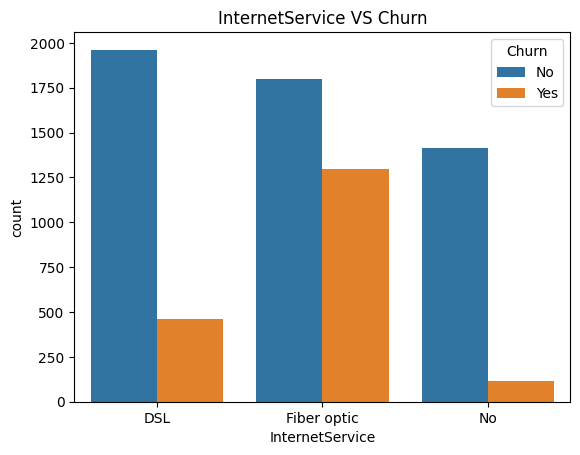

In [15]:
sns.countplot(data=df,
              x="InternetService",
              hue="Churn")
plt.title("InternetService VS Churn")
plt.show()

In [16]:
internet_churn=pd.crosstab(df["InternetService"],df["Churn"], normalize='index')*100
print(internet_churn)

Churn                   No        Yes
InternetService                      
DSL              81.040892  18.959108
Fiber optic      58.107235  41.892765
No               92.595020   7.404980


Observation:
#Fiber optic customers have the highest churn rate (41.89%).
#DSL customers have a much lower churn rate (18.96%).
#Customers without internet service have the lowest churn rate (7.40%).

Business Insight:
#Internet service type appears to have a strong relationship with churn.
#Fiber optic customers represent a high-risk customer segment.
#The company should investigate why fiber optic users are leaving at such a high rate.
#Factors such as pricing, service quality, customer expectations, or competitor offerings may be contributing to churn.

In [17]:
df['TotalCharges']=pd.to_numeric(
    df['TotalCharges'],
    errors='coerce'
)

In [18]:
df[['tenure','MonthlyCharges','TotalCharges']].corr()

,tenure,MonthlyCharges,TotalCharges
tenure,1.00000,0.247900,0.825880
MonthlyCharges,0.24790,1.000000,0.651065
TotalCharges,0.82588,0.651065,1.000000


In [19]:
df['TotalCharges'].isnull().sum()

np.int64(11)

In [20]:
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

# Phase 3: Data Cleaning

In [21]:
df[df["TotalCharges"].isnull()]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


In [22]:
df["TotalCharges"]=df["TotalCharges"].fillna(0)

Observation:
#11 records contained missing values in TotalCharges.
#All affected customers had tenure = 0.
#These customers had recently joined the company and had not accumulated any charges yet.

Action Taken:
#Missing values in TotalCharges were replaced with 0.

Justification:
#Since total charges depend on the duration of service, customers with zero tenure are expected to have zero total charges.
#Replacing the missing values with 0 preserves the records while maintaining business consistency.

In [23]:
df.duplicated().sum()

np.int64(0)

In [24]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [25]:
customer_ids=df["customerID"]

In [26]:
df.drop("customerID",axis=1,inplace=True)

In [27]:
for col in df.select_dtypes(include=['object','string']).columns:
    print(f"\n{col}")
    print(df[col].unique())


gender
<ArrowStringArray>
['Female', 'Male']
Length: 2, dtype: str

Partner
<ArrowStringArray>
['Yes', 'No']
Length: 2, dtype: str

Dependents
<ArrowStringArray>
['No', 'Yes']
Length: 2, dtype: str

PhoneService
<ArrowStringArray>
['No', 'Yes']
Length: 2, dtype: str

MultipleLines
<ArrowStringArray>
['No phone service', 'No', 'Yes']
Length: 3, dtype: str

InternetService
<ArrowStringArray>
['DSL', 'Fiber optic', 'No']
Length: 3, dtype: str

OnlineSecurity
<ArrowStringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str

OnlineBackup
<ArrowStringArray>
['Yes', 'No', 'No internet service']
Length: 3, dtype: str

DeviceProtection
<ArrowStringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str

TechSupport
<ArrowStringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str

StreamingTV
<ArrowStringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str

StreamingMovies
<ArrowStringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: 

Data Cleaning Summary:
#Converted Total Charges from object to numeric.
#Replaced 11 missing values in Total Charges with 0 based on business logic.
#Verified that no duplicate records exist.
#Removed CustomerID because it is an identifier and not a predictive feature.
#Identified numerical and categorical variables for further preprocessing.

# Phase 4: Feature Engineering & Train-test split

In [28]:
for col in df.select_dtypes(include=['object','string']).columns:
    print(col)
    print(df[col].unique())
    print('-'*50)

gender
<ArrowStringArray>
['Female', 'Male']
Length: 2, dtype: str
--------------------------------------------------
Partner
<ArrowStringArray>
['Yes', 'No']
Length: 2, dtype: str
--------------------------------------------------
Dependents
<ArrowStringArray>
['No', 'Yes']
Length: 2, dtype: str
--------------------------------------------------
PhoneService
<ArrowStringArray>
['No', 'Yes']
Length: 2, dtype: str
--------------------------------------------------
MultipleLines
<ArrowStringArray>
['No phone service', 'No', 'Yes']
Length: 3, dtype: str
--------------------------------------------------
InternetService
<ArrowStringArray>
['DSL', 'Fiber optic', 'No']
Length: 3, dtype: str
--------------------------------------------------
OnlineSecurity
<ArrowStringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str
--------------------------------------------------
OnlineBackup
<ArrowStringArray>
['Yes', 'No', 'No internet service']
Length: 3, dtype: str
--------------------

In [29]:
for col in[
    'Contract',
    'InternetService',
    'PaymentMethod',
    'OnlineSecurity',
    'TechSupport']:
    print("\n",col)
    print(df[col].value_counts())


 Contract
Contract
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64

 InternetService
InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64

 PaymentMethod
PaymentMethod
Electronic check             2365
Mailed check                 1612
Bank transfer (automatic)    1544
Credit card (automatic)      1522
Name: count, dtype: int64

 OnlineSecurity
OnlineSecurity
No                     3498
Yes                    2019
No internet service    1526
Name: count, dtype: int64

 TechSupport
TechSupport
No                     3473
Yes                    2044
No internet service    1526
Name: count, dtype: int64


In [30]:
binary_cols=["gender","Partner","Dependents","PhoneService","PaperlessBilling","Churn"]
df["gender"]=df["gender"].map({
    "Female":1,"Male":0})
for col in binary_cols[1:]:
    df[col]=df[col].map({
        "Yes":1,"No":0})

In [31]:
df[binary_cols].head()

,gender,Partner,Dependents,PhoneService,PaperlessBilling,Churn
0,1,1,0,0,1,0
1,0,0,0,1,0,0
2,0,0,0,1,1,1
3,0,0,0,0,0,0
4,1,0,0,1,1,1


In [32]:
multi_cat_cols=["MultipleLines","InternetService","OnlineBackup","OnlineSecurity","DeviceProtection",
                "TechSupport","StreamingMovies","StreamingTV","Contract","PaymentMethod"]
df=pd.get_dummies(
    df,
    columns=multi_cat_cols,
    drop_first=True)

In [33]:
df.shape

(7043, 31)

In [34]:
df.select_dtypes(include=['object','string']).columns

Index([], dtype='str')

In [35]:
x=df.drop("Churn",axis=1)
y=df["Churn"]

In [36]:
print(x.shape)
print(y.shape)

(7043, 30)
(7043,)


In [37]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test =train_test_split(
    x,y,test_size=0.2, random_state=42)

In [38]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(5634, 30)
(1409, 30)
(5634,)
(1409,)


In [39]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 31 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   gender                                 7043 non-null   int64  
 1   SeniorCitizen                          7043 non-null   int64  
 2   Partner                                7043 non-null   int64  
 3   Dependents                             7043 non-null   int64  
 4   tenure                                 7043 non-null   int64  
 5   PhoneService                           7043 non-null   int64  
 6   PaperlessBilling                       7043 non-null   int64  
 7   MonthlyCharges                         7043 non-null   float64
 8   TotalCharges                           7043 non-null   float64
 9   Churn                                  7043 non-null   int64  
 10  MultipleLines_No phone service         7043 non-null   bool   
 11  MultipleLines_Y

In [40]:
bool_cols=df.select_dtypes(include="bool").columns
df[bool_cols]=df[bool_cols].astype(int)

In [41]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 31 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   gender                                 7043 non-null   int64  
 1   SeniorCitizen                          7043 non-null   int64  
 2   Partner                                7043 non-null   int64  
 3   Dependents                             7043 non-null   int64  
 4   tenure                                 7043 non-null   int64  
 5   PhoneService                           7043 non-null   int64  
 6   PaperlessBilling                       7043 non-null   int64  
 7   MonthlyCharges                         7043 non-null   float64
 8   TotalCharges                           7043 non-null   float64
 9   Churn                                  7043 non-null   int64  
 10  MultipleLines_No phone service         7043 non-null   int64  
 11  MultipleLines_Y

# Phase 5: Logistic Regression

In [42]:
from sklearn.preprocessing import StandardScaler

In [43]:
scaler=StandardScaler()
Xtrain_scaled=scaler.fit_transform(X_train)
Xtest_scaled=scaler.transform(X_test)

In [44]:
print(Xtrain_scaled[:5])

[[ 1.02516569e+00 -4.37749204e-01 -9.69578591e-01  1.53218588e+00
  -4.65683364e-01  3.29573443e-01 -1.20000722e+00 -4.73723375e-04
  -4.19924521e-01 -3.29573443e-01 -8.60523366e-01 -8.87056733e-01
  -5.24080751e-01 -5.24080751e-01 -7.33828011e-01 -5.24080751e-01
   1.58094240e+00 -5.24080751e-01  1.38479574e+00 -5.24080751e-01
  -6.37762944e-01 -5.24080751e-01  1.25076217e+00 -5.24080751e-01
  -7.94748183e-01  1.91010860e+00 -5.58352808e-01 -5.27655848e-01
  -7.09649831e-01  1.84247002e+00]
 [ 1.02516569e+00 -4.37749204e-01 -9.69578591e-01 -6.52662324e-01
   8.85536787e-01  3.29573443e-01  8.33328321e-01  1.07475386e+00
   1.25601669e+00 -3.29573443e-01  1.16208349e+00  1.12732361e+00
  -5.24080751e-01 -5.24080751e-01  1.36271713e+00 -5.24080751e-01
  -6.32534113e-01 -5.24080751e-01 -7.22128160e-01 -5.24080751e-01
  -6.37762944e-01 -5.24080751e-01  1.25076217e+00 -5.24080751e-01
   1.25826019e+00 -5.23530443e-01  1.79098231e+00 -5.27655848e-01
  -7.09649831e-01 -5.42749671e-01]
 [-9.7

In [45]:
from sklearn.linear_model import LogisticRegression
model=LogisticRegression(random_state=42)
model.fit(Xtrain_scaled,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [46]:
y_pred=model.predict(Xtest_scaled)

In [47]:
from sklearn.metrics import accuracy_score
accuracy=accuracy_score(y_test,y_pred)
print("Accuracy",accuracy)

Accuracy 0.8204400283889283


In [48]:
from sklearn.metrics import confusion_matrix,classification_report
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))

[[934 102]
 [151 222]]
              precision    recall  f1-score   support

           0       0.86      0.90      0.88      1036
           1       0.69      0.60      0.64       373

    accuracy                           0.82      1409
   macro avg       0.77      0.75      0.76      1409
weighted avg       0.81      0.82      0.82      1409



# Phase 6: Decision Trees

In [49]:
from sklearn.tree import DecisionTreeClassifier
dt_model=DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train,y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

In [50]:
y_pred_dt=dt_model.predict(X_test)

In [51]:
accuracy_dt=accuracy_score(y_test,y_pred_dt)
print("Decision Tree accuracy:",accuracy_dt)

Decision Tree accuracy: 0.7118523775727467


In [52]:
train_pred=dt_model.predict(X_train)
train_accuracy=accuracy_score(y_train,train_pred)
print("Training Accuracy:",train_accuracy)

Training Accuracy: 0.9985800496982605


In [53]:
print(confusion_matrix(y_test,y_pred_dt))
print(classification_report(y_test,y_pred_dt))

[[835 201]
 [205 168]]
              precision    recall  f1-score   support

           0       0.80      0.81      0.80      1036
           1       0.46      0.45      0.45       373

    accuracy                           0.71      1409
   macro avg       0.63      0.63      0.63      1409
weighted avg       0.71      0.71      0.71      1409



In [54]:
depths=[1,2,3,4,5,6,7,8,10]
for depth in depths:
    dtc_model=DecisionTreeClassifier(max_depth=depth, random_state=42)
    dtc_model.fit(X_train,y_train)
    train_acc=accuracy_score(y_train, dtc_model.predict(X_train))
    test_acc=accuracy_score(y_test, dtc_model.predict(X_test))
    print(f"depth-{depth} | " f"Train : {train_acc:.3f} | " f"Test : {test_acc:.3f}")

depth-1 | Train : 0.734 | Test : 0.735
depth-2 | Train : 0.787 | Test : 0.802
depth-3 | Train : 0.787 | Test : 0.802
depth-4 | Train : 0.790 | Test : 0.803
depth-5 | Train : 0.797 | Test : 0.806
depth-6 | Train : 0.802 | Test : 0.798
depth-7 | Train : 0.818 | Test : 0.789
depth-8 | Train : 0.834 | Test : 0.788
depth-10 | Train : 0.874 | Test : 0.765


In [55]:
best_tree=DecisionTreeClassifier(max_depth=5 ,random_state=42)
best_tree.fit(X_train,y_train)
y_pred_best=best_tree.predict(X_test)

In [56]:
print(confusion_matrix(y_test,y_pred_best))
print(classification_report(y_test,y_pred_best))

[[964  72]
 [201 172]]
              precision    recall  f1-score   support

           0       0.83      0.93      0.88      1036
           1       0.70      0.46      0.56       373

    accuracy                           0.81      1409
   macro avg       0.77      0.70      0.72      1409
weighted avg       0.80      0.81      0.79      1409



# Phase 7: Random Forest

In [57]:
from sklearn.ensemble import RandomForestClassifier
rf_model= RandomForestClassifier()
rf_model.fit(X_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [58]:
y_pred_rf=rf_model.predict(X_test)

In [59]:
Train_Accuracy_rf=accuracy_score(y_train, rf_model.predict(X_train))
print(Train_Accuracy_rf)

0.9984025559105432


In [60]:
Test_Accuracy_rf=accuracy_score(y_test,y_pred_rf)
print(Test_Accuracy_rf)

0.7970191625266146


In [61]:
print(confusion_matrix(y_test,y_pred_rf))
print(classification_report(y_test,y_pred_rf))

[[941  95]
 [191 182]]
              precision    recall  f1-score   support

           0       0.83      0.91      0.87      1036
           1       0.66      0.49      0.56       373

    accuracy                           0.80      1409
   macro avg       0.74      0.70      0.71      1409
weighted avg       0.79      0.80      0.79      1409



In [62]:
depths=[3,5,7,10]
estimators=[50,100,200]
for depth in depths:
    for n in estimators:
        rf=RandomForestClassifier(n_estimators=n , max_depth=depth, random_state=42)
        rf.fit(X_train,y_train)
        pred_y=rf.predict(X_test)
        train_acc=accuracy_score(y_train,rf.predict(X_train))
        test_Acc=accuracy_score(y_test,pred_y)
        print(
            f"Depth={depth} , Trees ={n}   | "
            f"Train ={train_acc:.3f}   |"
            f" Test={test_Acc:.3f}" )
        
        

Depth=3 , Trees =50   | Train =0.785   | Test=0.786
Depth=3 , Trees =100   | Train =0.785   | Test=0.789
Depth=3 , Trees =200   | Train =0.783   | Test=0.785
Depth=5 , Trees =50   | Train =0.798   | Test=0.801
Depth=5 , Trees =100   | Train =0.798   | Test=0.797
Depth=5 , Trees =200   | Train =0.799   | Test=0.796
Depth=7 , Trees =50   | Train =0.814   | Test=0.805
Depth=7 , Trees =100   | Train =0.814   | Test=0.809
Depth=7 , Trees =200   | Train =0.812   | Test=0.804
Depth=10 , Trees =50   | Train =0.864   | Test=0.807
Depth=10 , Trees =100   | Train =0.862   | Test=0.810
Depth=10 , Trees =200   | Train =0.863   | Test=0.810


In [63]:
best_rf=RandomForestClassifier( n_estimators=100, max_depth=10, random_state=42)
best_rf.fit(X_train,y_train)
y_pred_best_rf=best_rf.predict(X_test)
print(confusion_matrix(y_test,y_pred_best_rf))
print(classification_report(y_test,y_pred_best_rf))

[[947  89]
 [179 194]]
              precision    recall  f1-score   support

           0       0.84      0.91      0.88      1036
           1       0.69      0.52      0.59       373

    accuracy                           0.81      1409
   macro avg       0.76      0.72      0.73      1409
weighted avg       0.80      0.81      0.80      1409



# Phase 8: Feature Importance and Model Interpretation

In [64]:
coef_df=pd.DataFrame({ 
    "Feature":x.columns,
    "Coefficient":model.coef_[0]})
coef_df["Abs_Coefficient"]= coef_df["Coefficient"].abs()
coef_df=coef_df.sort_values(
    by="Abs_Coefficient",
    ascending=False)
coef_df.head(10)

,Feature,Coefficient,Abs_Coefficient
4,tenure,-1.347355,1.347355
8,TotalCharges,0.649427,0.649427
7,MonthlyCharges,-0.628014,0.628014
11,InternetService_Fiber optic,0.619853,0.619853
26,Contract_Two year,-0.613702,0.613702
25,Contract_One year,-0.268336,0.268336
22,StreamingMovies_Yes,0.228714,0.228714
24,StreamingTV_Yes,0.179380,0.179380
10,MultipleLines_Yes,0.168199,0.168199
6,PaperlessBilling,0.163829,0.163829


# Phase 9: Model Selection
Logistic Regression comes out to be best among all the models we have trained, as it has higher recall and F1-Score than the rest.

# Phase 10: Model Saving

In [65]:
import joblib

In [66]:
joblib.dump(model,"churn_model.pkl")
joblib.dump(scaler,"scaler.pkl")
print("Model and scaler saved successfully")

Model and scaler saved successfully


In [67]:
import os
print(os.listdir())

['.ipynb_checkpoints', 'churn_model.pkl', 'Customer_Churn_Analysis.ipynb', 'scaler.pkl']


In [68]:
loaded_model=joblib.load("churn_model.pkl")
loaded_scaler=joblib.load("scaler.pkl")
print(type(loaded_model))
print(type(loaded_scaler))

<class 'sklearn.linear_model._logistic.LogisticRegression'>
<class 'sklearn.preprocessing._data.StandardScaler'>


In [69]:
feature_names=x.columns.tolist()
joblib.dump(feature_names,"feature_names.pkl")

['feature_names.pkl']

# Phase 11: SHAP (Explainability)

In [70]:
import shap
explainer=shap.Explainer(model,Xtrain_scaled)
shap_values=explainer(Xtest_scaled)

Background dataset has 5634 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=5634 when initializing the masker.


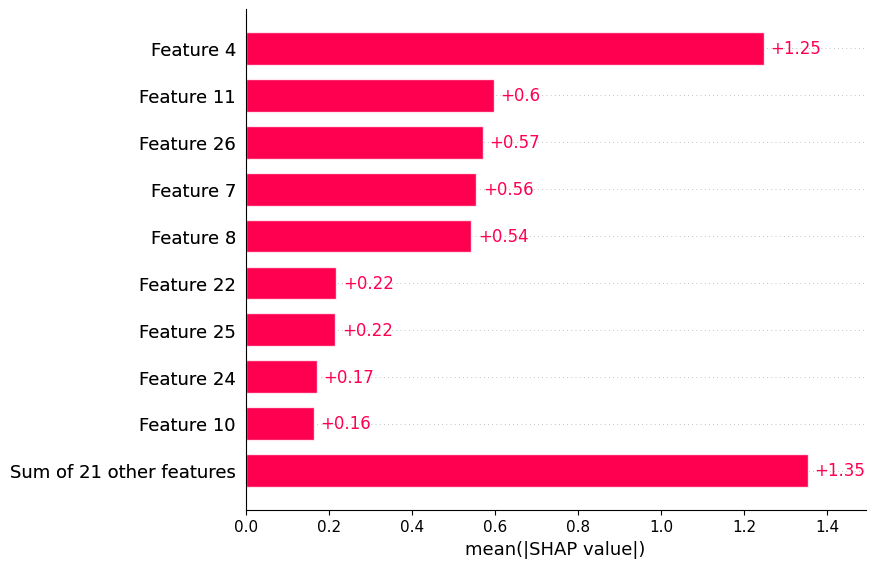

In [71]:
shap.plots.bar(shap_values)

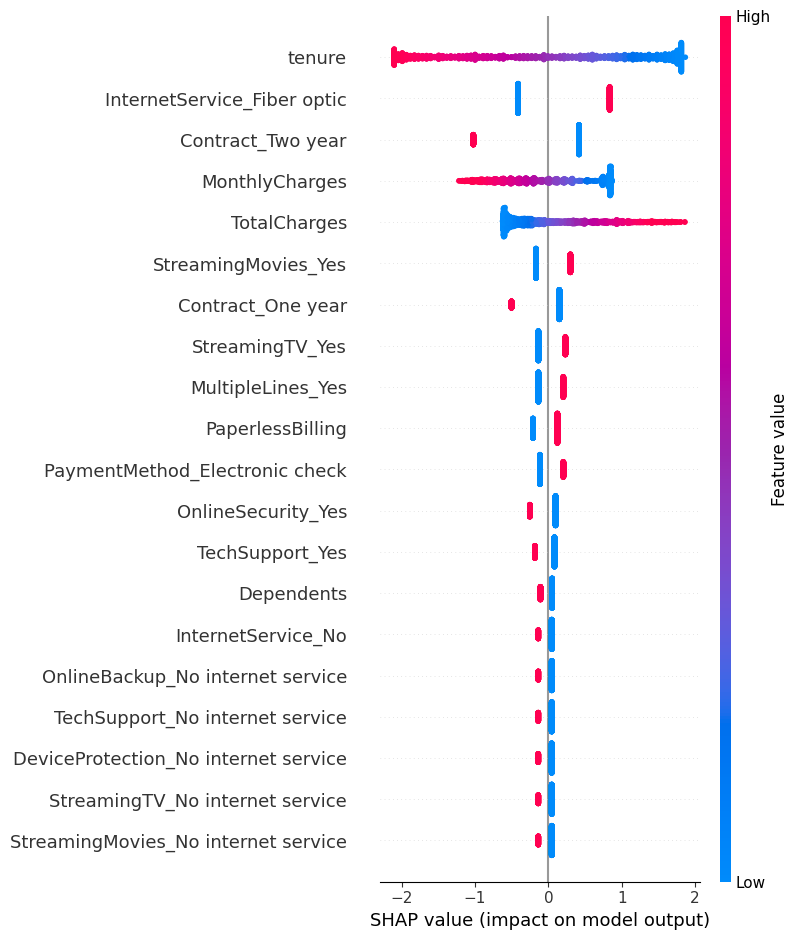

In [72]:
shap.summary_plot(shap_values.values, X_test ,feature_names=x.columns)

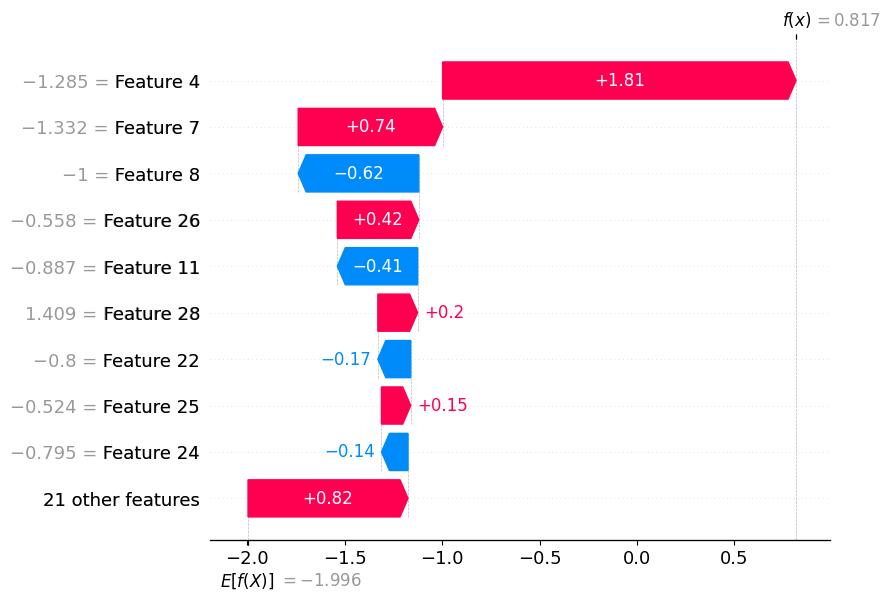

In [73]:
shap.plots.waterfall(shap_values[0])

In [77]:
background_data=Xtrain_scaled[:100]
joblib.dump(
    background_data,
    "../models/background_data.pkl"
)

['../models/background_data.pkl']